In [1]:
import pathlib

import numpy as np
import nibabel as nib
from nilearn import masking
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns
import colorcet
import bct
from tqdm.notebook import tqdm

import pymcm

%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

# Average SC from TUM data

In [2]:
fname = '/RAID1/jupytertmp/mcm/data/data_group-tum.joblib'
tum_group = joblib.load(fname)

# Network averages 

In [3]:
rootdir = pathlib.Path('/RAID1/jupytertmp/mcm/data/external/hcp')
subjects = [p.stem for p in rootdir.glob('*')]

corrupted = ['128632', '146432', '131217', '110411', '101107']
for s in corrupted:
    subjects.remove(s)

In [4]:
group = pymcm.data.Group(name='HCP')

In [5]:
idcs = tum_group['roi_template'] - 1

for subject in tqdm(subjects):

    data_file = f'{rootdir}/{subject}/sub-{subject}_data.joblib'
    sub = joblib.load(data_file)

    # Calculate logratio
    degree = sub.fmri['degree']
    cmrglc_adj = sub.pet['roiavgs'] / degree
    logratio = pymcm.processing.pet_logratio(cmrglc_adj)
    dir_weights, undir_weights = pymcm.processing.logratio_to_weights(logratio)

    sub.pet.add_derivs(
        cmrglc_adj=cmrglc_adj,
        logratio=logratio,
        dir_weights=dir_weights, 
        undir_weights=undir_weights
        )
    
    # Remove some data to clear up memory
    for img in sub.iterraw():
        img.raw.clear()
        for key in ['voxint_mask', 'masked_data', 'masked_labels', 'roiavgs']:
            if key not in img.deriv.keys():
                continue
            del img.deriv[key]

    # Select the same rois as in the tum dataset
    sub.fmri.add_derivs(
        fc=sub.fmri['fc'][np.ix_(idcs, idcs)],
        pfc=sub.fmri['pfc'][np.ix_(idcs, idcs)],
        degree=sub.fmri['degree'][idcs]
    )
    sub.dwi.add_derivs(
        sc_raw=sub.dwi['sc_raw'][np.ix_(idcs,idcs)],
        sc_bin=sub.dwi['sc_bin'][np.ix_(idcs,idcs)],
        sc_weight=sub.dwi['sc_weight'][np.ix_(idcs,idcs)],
        sc_thr=sub.dwi['sc_thr'][np.ix_(idcs,idcs)],
        counts=sub.dwi['counts'][idcs],
        degree=sub.dwi['degree'][idcs],
    )
    sub.pet.add_derivs(
        cmrglc_adj=sub.pet['cmrglc_adj'][idcs],
        logratio=sub.pet['logratio'][np.ix_(idcs,idcs)],
        dir_weights=sub.pet['dir_weights'][np.ix_(idcs,idcs)],
        undir_weights=sub.pet['undir_weights'][np.ix_(idcs,idcs)],
    )
    
    group.add_raw(sub.name, sub)    

  0%|          | 0/95 [00:00<?, ?it/s]

# Directed and undirected

In [6]:
for sub in group.iterraw():

    fc = sub.fmri['fc']
    sc = sub.dwi['sc_thr']

    dir_weight = sub.pet['dir_weights']
    undir_weight = sub.pet['undir_weights']

    connectivity = sc * fc
    # connectivity = sub.dwi['sc_weight']
    directed = connectivity * dir_weight
    undirected = connectivity * undir_weight

    assert np.allclose(connectivity, undirected + directed + directed.T)

    sub.add_derivs(
        connectivity=connectivity,
        directed=directed, 
        undirected=undirected
    )


# Network averages

In [7]:
labels = tum_group['net_template']
for sub in group.iterraw():
    netstats = pymcm.processing.matrix_label_aggregate(sub['directed'], labels)
    sub.add_derivs(netstats=netstats)

In [8]:
group.add_derivs(
    fc =            np.mean([sub.fmri['fc'] for sub in group.iterraw()], axis=0),
    pfc =           np.mean([sub.fmri['pfc'] for sub in group.iterraw()], axis=0),
    sc_thr =        np.mean([sub.dwi['sc_thr'] for sub in group.iterraw()], axis=0),
    sc_weight =     np.mean([sub.dwi['sc_weight'] for sub in group.iterraw()], axis=0),
    logratio =      np.mean([sub.pet['logratio'] for sub in group.iterraw()], axis=0),
    # 
    connectivity =  np.mean([sub['connectivity'] for sub in group.iterraw()], axis=0),
    directed =      np.mean([sub['directed'] for sub in group.iterraw()], axis=0),
    undirected =    np.mean([sub['undirected'] for sub in group.iterraw()], axis=0),
    # 
    netavg_percent_in =     np.mean([sub['netstats']['degree_in_percent'] for sub in group.iterraw()], axis=0),
    netavg_percent_out =    np.mean([sub['netstats']['degree_out_percent'] for sub in group.iterraw()], axis=0),
    netavg_wrt_outputs =    np.mean([sub['netstats']['avg_outputs'] for sub in group.iterraw()], axis=0),
    netavg_wrt_inputs =     np.mean([sub['netstats']['avg_inputs'] for sub in group.iterraw()], axis=0),
    netavg_wrt_reciprocal = np.mean([sub['netstats']['avg_reciprocal'] for sub in group.iterraw()], axis=0),
    netavg_wrt_mixed =      np.mean([sub['netstats']['avg_mixed'] for sub in group.iterraw()], axis=0),
    netavg_mean =           np.mean([sub['netstats']['avgs'] for sub in group.iterraw()], axis=0),
)

In [9]:
group.add_derivs(
    roi_template=tum_group['roi_template'],
    net_template=tum_group['net_template']
)

# Visualize the group average matrices

Text(0.5, 1.0, 'Unirected avg')

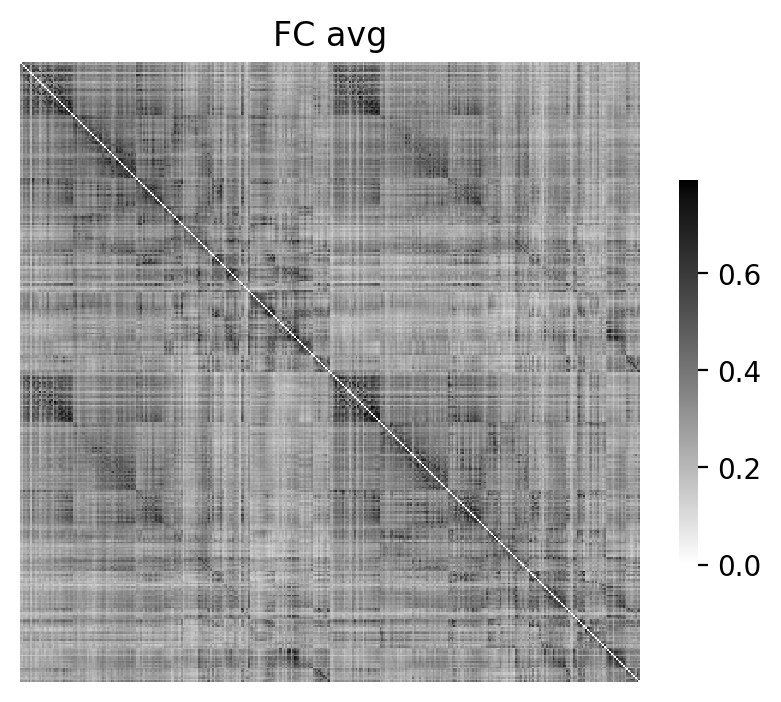

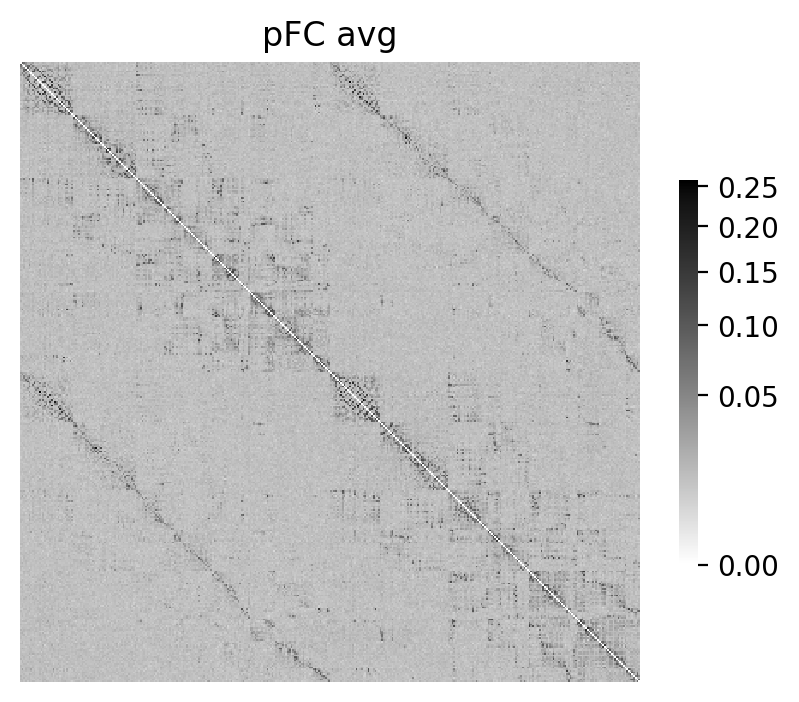

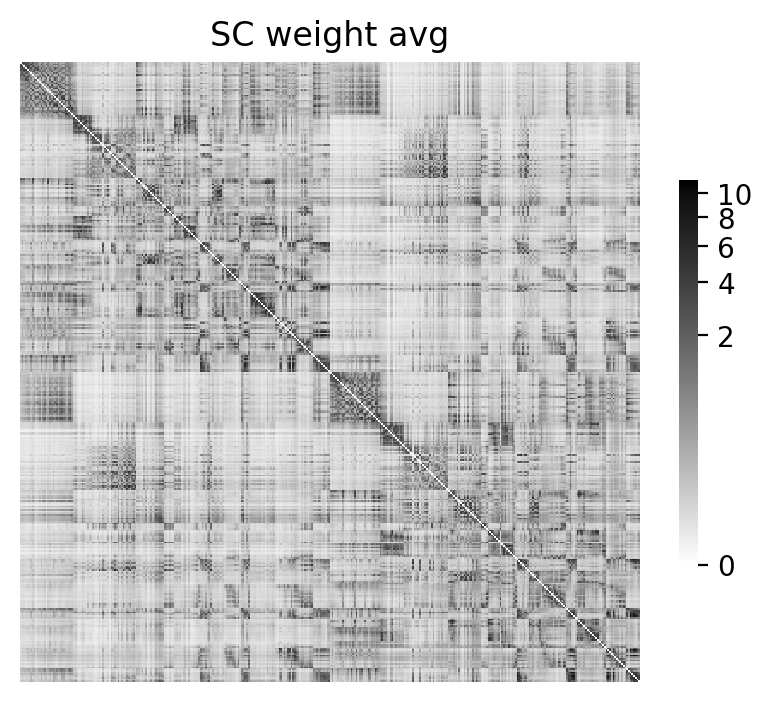

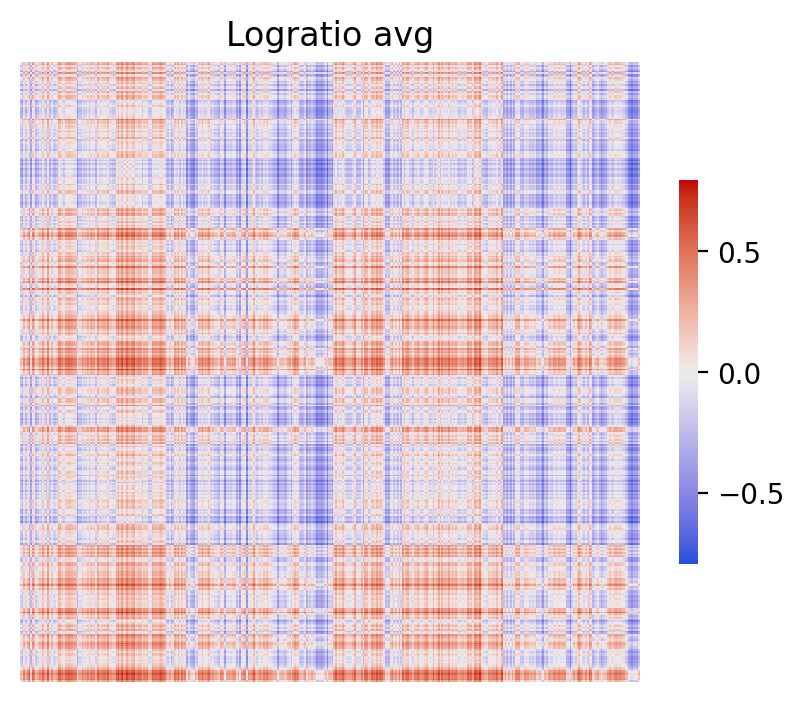

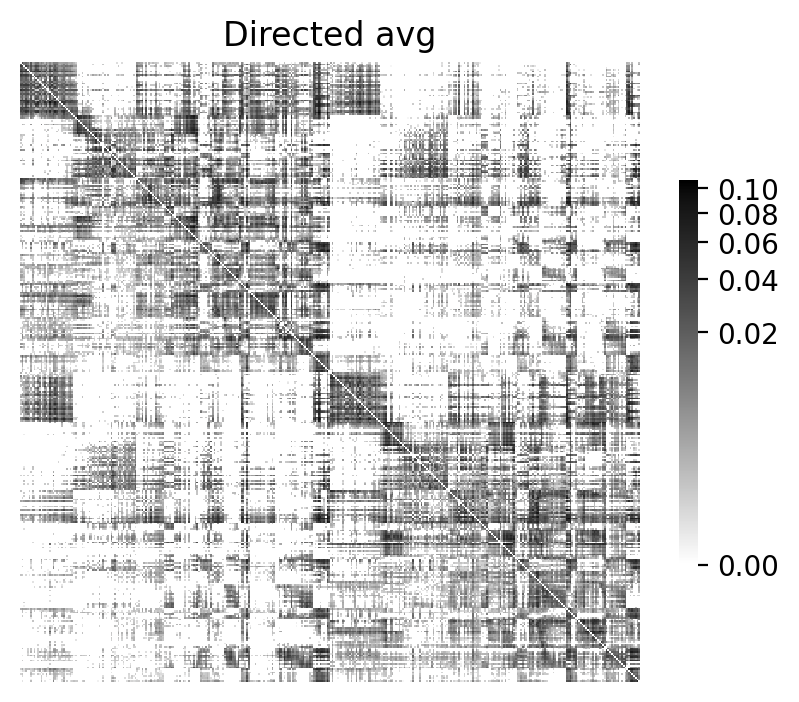

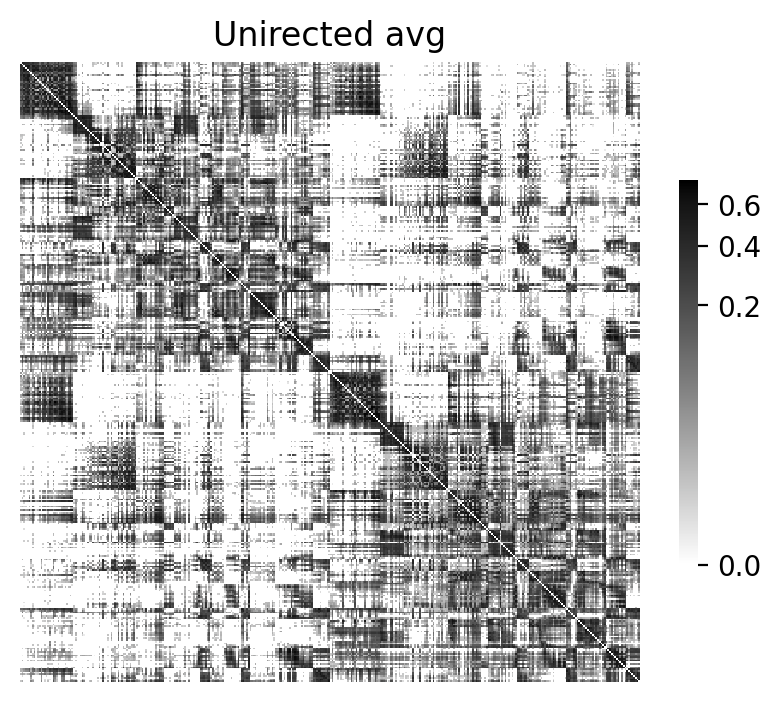

In [10]:
fig, ax = plt.subplots(figsize=(5,5))
sns.heatmap(group['fc'], square=True, cbar=True, cbar_kws=dict(shrink=0.5), cmap='cet_CET_L1_r', ax=ax)
ax.axis('off')
ax.set_title('FC avg')

fig, ax = plt.subplots(figsize=(5,5))
sns.heatmap(group['pfc'], square=True, cbar=True, cbar_kws=dict(shrink=0.5), cmap='cet_CET_L1_r', ax=ax, norm=colors.PowerNorm(0.5))
ax.axis('off')
ax.set_title('pFC avg')

fig, ax = plt.subplots(figsize=(5,5))
sns.heatmap(group['sc_weight'], square=True, cbar=True, cbar_kws=dict(shrink=0.5), cmap='cet_CET_L1_r', ax=ax, norm=colors.PowerNorm(0.3))
ax.axis('off')
ax.set_title('SC weight avg')

fig, ax = plt.subplots(figsize=(5,5))
sns.heatmap(group['logratio'], square=True, cbar=True, cbar_kws=dict(shrink=0.5), cmap='cet_CET_D1', ax=ax)
ax.axis('off')
ax.set_title('Logratio avg')

fig, ax = plt.subplots(figsize=(5,5))
sns.heatmap(group['directed'], square=True, cbar=True, cbar_kws=dict(shrink=0.5), cmap='cet_CET_L1_r', ax=ax, norm=colors.PowerNorm(0.3))
ax.axis('off')
ax.set_title('Directed avg')

fig, ax = plt.subplots(figsize=(5,5))
sns.heatmap(group['undirected'], square=True, cbar=True, cbar_kws=dict(shrink=0.5), cmap='cet_CET_L1_r', ax=ax, norm=colors.PowerNorm(0.3))
ax.axis('off')
ax.set_title('Unirected avg')

# fig, ax = plt.subplots(figsize=(5,5))
# sns.heatmap(group['net_avg'], square=True, cbar=False, cmap='cet_CET_L18', ax=ax)
# ax.set(xticklabels=np.unique(group['net_template']), yticklabels=np.unique(group['net_template']))
# ax.set_title('Network directed avg')

# Save data

In [11]:
fname = '/RAID1/jupytertmp/mcm/data/data_group-hcp.joblib'
_ = joblib.dump(group, fname)

---

In [97]:
import networkx as nx
from scipy import stats
from sklearn.linear_model import HuberRegressor

In [86]:
tum = joblib.load('/RAID1/jupytertmp/mcm/data/model-1_group-TUM.joblib')
hcp = joblib.load('/RAID1/jupytertmp/mcm/data/model-1_group-HCP.joblib')

In [ ]:
derivs = ['fc', 'sc_weight', 'logratio', 'connectivity', 'directed', 'undirected', 'netavg_wrt_mixed']
for deriv in derivs:
    stat, p = stats.pearsonr(pymcm.array.vectorize_matrix(hcp[deriv]), pymcm.array.vectorize_matrix(tum[deriv]))
    print(f'{deriv.upper():>20}: {stat:.3f}')

In [ ]:
distance_FC(hcp['directed'], tum['directed']).geodesic()

In [99]:
dir_hcp = pymcm.array.vectorize_matrix(hcp['directed'])
dir_tum = pymcm.array.vectorize_matrix(tum['directed'])

huber = HuberRegressor(fit_intercept=True).fit(dir_tum[:, np.newaxis], dir_hcp)

In [ ]:
huber.intercept_

In [104]:
f = lambda xs, model: model.intercept_ + xs * model.coef_[0]

In [ ]:
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(dir_tum, dir_hcp, marker='.', s=1, alpha=0.1)
xs = np.array([dir_tum.min(), dir_tum.max()])
ax.plot(xs, f(xs, huber), color='crimson')

ax.set(xscale='log', yscale='log')

In [ ]:
xs

In [64]:
class distance_FC(object):
    def __init__(self, FC1, FC2, eig_thresh=10**(-3)):
        self.FC1 = FC1
        self.FC2 = FC2
        self.eig_thresh = eig_thresh

        # ensure symmetric
        self.FC1 = self._ensure_symmetric(self.FC1)
        self.FC2 = self._ensure_symmetric(self.FC2)

    def _info(self, s):
        print('INFO: %s' % s)

    def _ensure_symmetric(self, Q):
        '''
        computation is sometimes not precise (round errors),
        so ensure matrices that are supposed to be
        symmetric are symmetric
        '''
        return (Q + np.transpose(Q))/2

    def _vectorize(self, Q):
        '''
        given a symmetric matrix (FC), return unique
        elements as an array. Ignore diagonal elements
        '''
        # extract lower triangular matrix
        tri = np.tril(Q, -1)

        vec = []
        for ii in range(1, tri.shape[0]):
            for jj in range(ii):
                vec.append(tri[ii, jj])
        
        return np.asarray(vec)

    def geodesic(self):
        '''
        dist = sqrt(trace(log^2(M)))
        M = Q_1^{-1/2}*Q_2*Q_1^{-1/2}
        '''
        # compute Q_1^{-1/2} via eigen value decmposition
        u, s, _ = np.linalg.svd(self.FC1, full_matrices=True)

        ## lift very small eigen values
        for ii, s_ii in enumerate(s):
            if s_ii < self.eig_thresh:
                s[ii] = self.eig_thresh

        '''
        since FC1 is in S+, u = v, u^{-1} = u'
        FC1 = usu^(-1)
        FC1^{1/2} = u[s^{1/2}]u'
        FC1^{-1/2} = u[s^{-1/2}]u'
        '''
        FC1_mod = u @ np.diag(s**(-1/2)) @ np.transpose(u)
        M = FC1_mod @ self.FC2 @ FC1_mod

        '''
        trace = sum of eigenvalues;
        np.logm might have round errors,
        implement using svd instead
        '''
        _, s, _ = np.linalg.svd(M, full_matrices=True)

        return np.sqrt(np.sum(np.log(s)**2))

    def pearson(self):
        '''
        conventional Pearson distance between
        two FC matrices. The matrices are vectorized
        '''
        vec1 = self._vectorize(self.FC1)
        vec2 = self._vectorize(self.FC2)

        return (1 - np.corrcoef(vec1, vec2)[0, 1])/2